In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('/content/drive/MyDrive/FYP_Fraud_Detection/fraudTrain_engineered.csv')
df_test = pd.read_csv('/content/drive/MyDrive/FYP_Fraud_Detection/fraudTest_engineered.csv')

target = 'is_fraud'
drop_cols = ['is_fraud', 'unix_time']

X_train = df_train.drop(columns=drop_cols)
y_train = df_train[target]
X_test = df_test.drop(columns=drop_cols)
y_test = df_test[target]

print(f"Train: {X_train.shape} | Fraud: {y_train.sum()}")
print(f"Test: {X_test.shape} | Fraud: {y_test.sum()}")

Train: (1296675, 14) | Fraud: 7506
Test: (555719, 14) | Fraud: 2145


In [ ]:
# Load original data to get card numbers and timestamps for sequencing
df_train_orig = pd.read_csv('/content/drive/MyDrive/FYP_Fraud_Detection/fraudTrain.csv')
df_test_orig = pd.read_csv('/content/drive/MyDrive/FYP_Fraud_Detection/fraudTest.csv')

# Add card number back for grouping sequences
X_train['cc_num'] = df_train_orig['cc_num'].values
X_train['trans_date_trans_time'] = df_train_orig['trans_date_trans_time'].values
X_test['cc_num'] = df_test_orig['cc_num'].values
X_test['trans_date_trans_time'] = df_test_orig['trans_date_trans_time'].values

print(f"Unique cards in train: {X_train['cc_num'].nunique()}")
print(f"Unique cards in test: {X_test['cc_num'].nunique()}")

Unique cards in train: 983
Unique cards in test: 924


# LSTM + Random Forest Hybrid Model

## Data Loading and Sequence Preparation

This notebook builds the hybrid LSTM + Random Forest model for credit card fraud detection. The same pre-processed engineered datasets from the EDA notebook are loaded, containing 1,296,675 training transactions and 555,719 test transactions across 14 features.

The key difference from the XGBoost standalone notebook is the addition of transaction sequencing. XGBoost treats every transaction independently — it reads one row at a time with no knowledge of what happened before. The LSTM component of the hybrid model requires the opposite: it reads a sequence of recent transactions from the same card in chronological order, looking for patterns in how spending behaviour changes over time.

To build these sequences, the original card numbers and timestamps are temporarily re-attached to the engineered features. Card numbers are used to group transactions by cardholder, and timestamps ensure the sequences are in the correct chronological order. These columns are used only for grouping and sorting — they are not fed into the model as features.

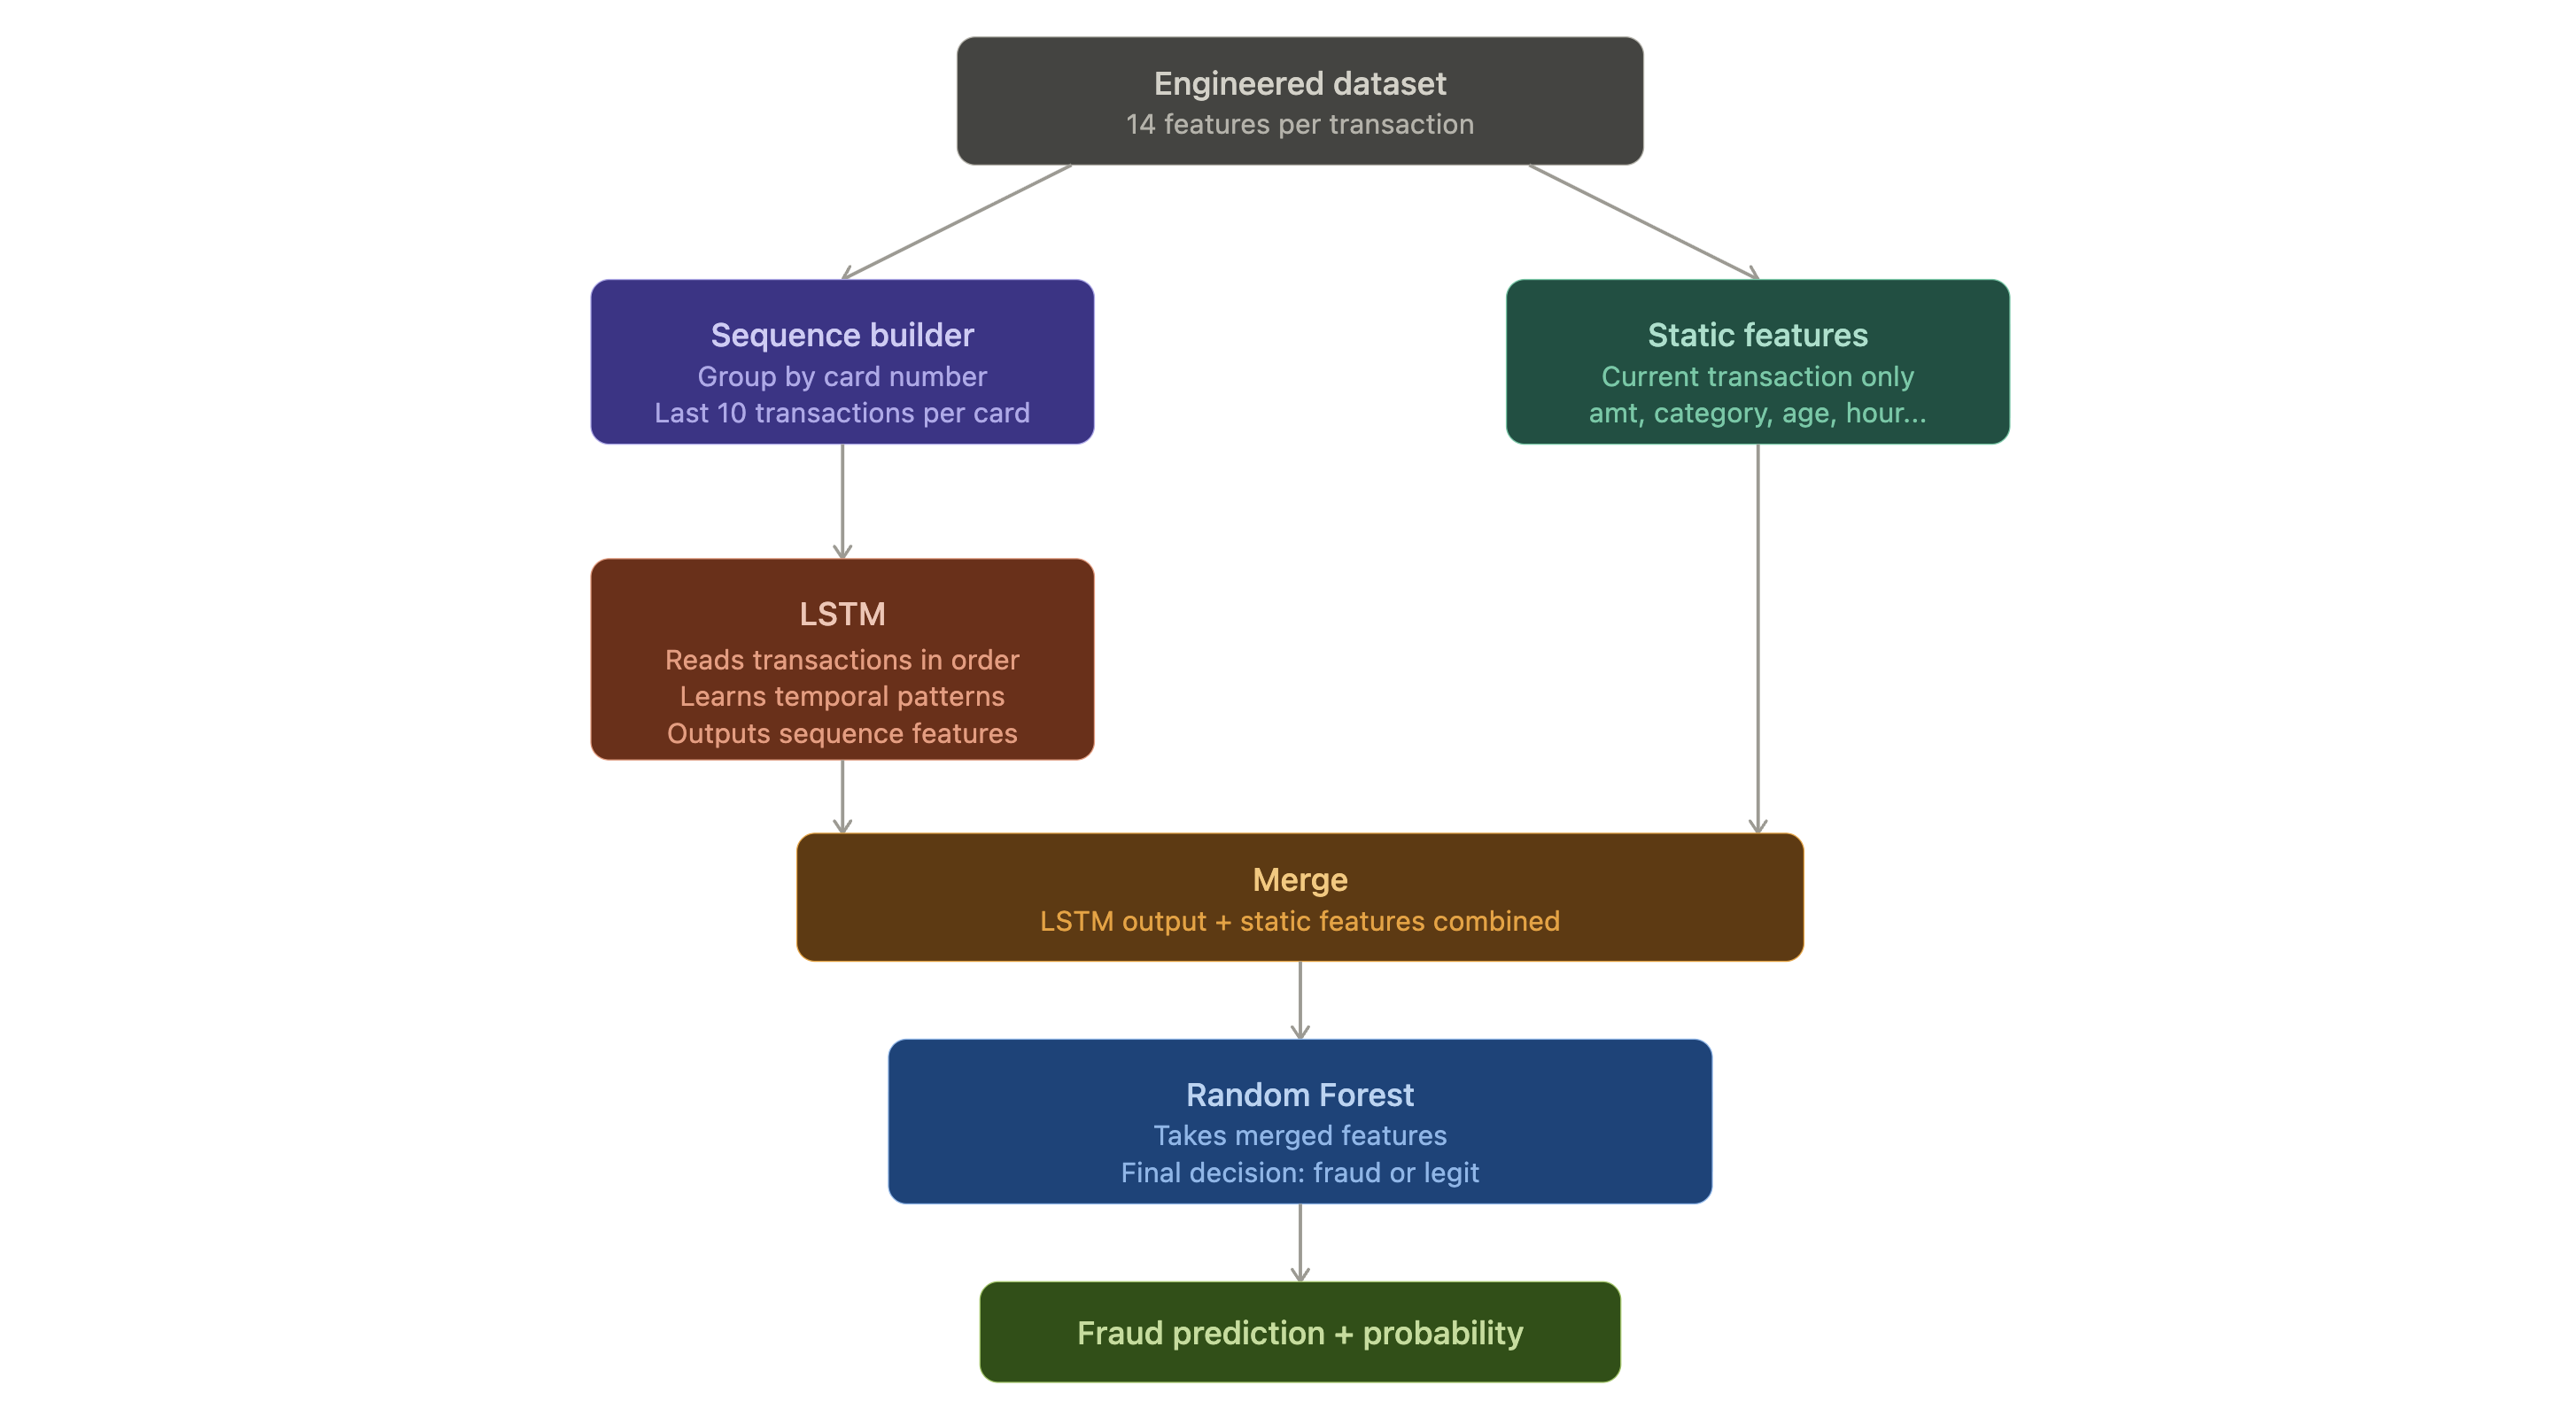

In [ ]:
from IPython.display import Image, display
display(Image('/content/drive/MyDrive/FYP_Fraud_Detection/hybrid_architecture.png', width=1000))

In [ ]:
# ============================================================
# CELL 4: BUILD TRANSACTION SEQUENCES FOR LSTM
# ============================================================
# Why sequences? XGBoost reads one transaction at a time.
# LSTM reads multiple transactions in ORDER — like reading
# a card's recent history. If a card had 5 purchases in
# the last hour, LSTM sees all 5 in order and spots the
# pattern. That's the whole point of the hybrid approach.
# ============================================================

from sklearn.preprocessing import StandardScaler
import numpy as np

# ----------------------------------------------------------
# Step 1: Identify which columns are actual features
# We added cc_num and trans_date_trans_time temporarily
# just for grouping and sorting. They are NOT model features.
# ----------------------------------------------------------
feature_cols = [c for c in X_train.columns if c not in ['cc_num', 'trans_date_trans_time']]
print(f"Features for model: {feature_cols}")
print(f"Number of features: {len(feature_cols)}")

# ----------------------------------------------------------
# Step 2: Scale all features to same range
# Why? LSTM is a neural network. Neural networks struggle
# when features have wildly different scales.
# amt ranges 0-10000, city_pop ranges 0-2000000, hour 0-23.
# StandardScaler converts everything to mean=0, std=1.
# fit_transform on train — learns the scaling rules
# transform on test — applies same rules (no data leakage)
# ----------------------------------------------------------
scaler = StandardScaler()
X_train[feature_cols] = scaler.fit_transform(X_train[feature_cols])
X_test[feature_cols] = scaler.transform(X_test[feature_cols])

# ----------------------------------------------------------
# Step 3: Sort by card number and time
# Why? LSTM reads transactions in chronological order.
# We need card 4521's transactions sorted oldest → newest.
# Without sorting, the sequences would be random order
# and LSTM can't learn any temporal patterns.
# We also temporarily attach the labels (y) so they stay
# aligned after sorting, then detach them again.
# ----------------------------------------------------------
X_train['y'] = y_train.values
X_train = X_train.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
y_train = X_train['y']
X_train = X_train.drop(columns=['y'])

X_test['y'] = y_test.values
X_test = X_test.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
y_test = X_test['y']
X_test = X_test.drop(columns=['y'])

# ----------------------------------------------------------
# Step 4: Define sequence length
# SEQ_LEN = 5 means for each transaction, LSTM looks at
# the LAST 5 transactions on that same card (including
# the current one). Like a sliding window.
#
# Example: Card 4521 has transactions T1, T2, T3, T4, T5, T6
# For T5, the sequence is [T1, T2, T3, T4, T5]
# For T6, the sequence is [T2, T3, T4, T5, T6]
#
# Why 5? Short enough to run fast on Colab.
# Long enough to capture rapid fraud patterns.
# ----------------------------------------------------------
SEQ_LEN = 5

# ----------------------------------------------------------
# Step 5: Function to build sequences per card
#
# For each transaction, this function:
# 1. Looks at the same card's previous transactions
# 2. Grabs the last SEQ_LEN transactions (the sequence)
# 3. If the card has fewer than SEQ_LEN transactions so far,
#    pads with zeros (e.g. card's 2nd ever transaction
#    gets [0, 0, 0, T1, T2] as its sequence)
# 4. Also saves the current transaction's static features
#    (these go to Random Forest, not LSTM)
# 5. Saves the label (fraud or legit) for that transaction
#
# Returns three arrays:
# - sequences: shape (num_transactions, SEQ_LEN, num_features)
#   This is what LSTM reads — 3D array
# - static_features: shape (num_transactions, num_features)
#   This is what Random Forest reads — 2D array
# - targets: shape (num_transactions,)
#   The fraud/legit labels
# ----------------------------------------------------------
def build_sequences(df, labels, feature_cols, seq_len):
    sequences = []        # Will hold all LSTM sequences
    static_features = []  # Will hold all RF static features
    targets = []          # Will hold all labels

    # Group all transactions by card number
    # Each group = one card's full transaction history
    grouped = df.groupby('cc_num')

    for card, group in grouped:
        # Get the feature values for this card's transactions
        # Already sorted by time from Step 3
        features = group[feature_cols].values

        # Get the labels for this card's transactions
        card_labels = labels.loc[group.index].values

        # Loop through each transaction on this card
        for i in range(len(group)):
            # Grab the last seq_len transactions up to and including current
            start = max(0, i - seq_len + 1)
            seq = features[start:i+1]

            # If this card doesn't have enough history yet, pad with zeros
            # E.g. card's 1st transaction: seq = [T1] → pad to [0,0,0,0,T1]
            # E.g. card's 3rd transaction: seq = [T1,T2,T3] → pad to [0,0,T1,T2,T3]
            if len(seq) < seq_len:
                padding = np.zeros((seq_len - len(seq), len(feature_cols)))
                seq = np.vstack([padding, seq])

            # Save the sequence (for LSTM)
            sequences.append(seq)

            # Save the current transaction features (for Random Forest)
            static_features.append(features[i])

            # Save the label
            targets.append(card_labels[i])

    return np.array(sequences), np.array(static_features), np.array(targets)

# ----------------------------------------------------------
# Step 6: Build the actual sequences
# This loops through all 1.29M training transactions
# grouped by 983 cards. Takes 3-5 minutes.
# ----------------------------------------------------------
print("Building training sequences...")
X_train_seq, X_train_static, y_train_seq = build_sequences(X_train, y_train, feature_cols, SEQ_LEN)
print(f"Train sequences: {X_train_seq.shape}")    # Expected: (1296675, 5, 14)
print(f"Train static: {X_train_static.shape}")      # Expected: (1296675, 14)
print(f"Train labels: {y_train_seq.shape} | Fraud: {int(y_train_seq.sum())}")

print("\nBuilding test sequences...")
X_test_seq, X_test_static, y_test_seq = build_sequences(X_test, y_test, feature_cols, SEQ_LEN)
print(f"Test sequences: {X_test_seq.shape}")        # Expected: (555719, 5, 14)
print(f"Test static: {X_test_static.shape}")          # Expected: (555719, 14)
print(f"Test labels: {y_test_seq.shape} | Fraud: {int(y_test_seq.sum())}")

Features for model: ['amt', 'city_pop', 'hour', 'month', 'distance_cardholder_merchant', 'age', 'is_weekend', 'is_night', 'velocity_1h', 'velocity_24h', 'amount_velocity_1h', 'category_encoded', 'gender_encoded', 'day_of_week_encoded']
Number of features: 14
Building training sequences...
Train sequences: (1296675, 5, 14)
Train static: (1296675, 14)
Train labels: (1296675,) | Fraud: 7506

Building test sequences...
Test sequences: (555719, 5, 14)
Test static: (555719, 14)
Test labels: (555719,) | Fraud: 2145


In [ ]:
# CELL 5: BUILD AND TRAIN LSTM
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout

# LSTM input: (sequence_length=5, features=14)
lstm_input = Input(shape=(SEQ_LEN, len(feature_cols)), name='sequence_input')
x = LSTM(64, return_sequences=False)(lstm_input)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
lstm_output = Dense(16, activation='relu', name='lstm_features')(x)

# Build model that extracts features (not classification yet)
lstm_model = Model(inputs=lstm_input, outputs=lstm_output)
lstm_model.summary()

# For training LSTM, add a temporary classification head
full_input = Input(shape=(SEQ_LEN, len(feature_cols)))
features = lstm_model(full_input)
output = Dense(1, activation='sigmoid')(features)
train_model = Model(inputs=full_input, outputs=output)

# Class weights to handle imbalance
fraud_ratio = (y_train_seq == 0).sum() / (y_train_seq == 1).sum()

train_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train — 5 epochs is enough for feature extraction
print(f"\nClass weight ratio: {fraud_ratio:.1f}")
print("Training LSTM...")
history = train_model.fit(
    X_train_seq, y_train_seq,
    epochs=5,
    batch_size=512,
    class_weight={0: 1, 1: fraud_ratio},
    validation_split=0.1,
    verbose=1
)
print("LSTM trained")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 5, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_features (Dense)           │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,832 (89.19 KB)

 Trainable params: 22,832 (89.19 KB)

 Non-trainable params: 0 (0.00 B)


Class weight ratio: 171.8
Training LSTM...
Epoch 1/5
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 64s 27ms/step - accuracy: 0.9293 - loss: 0.5755 - val_accuracy: 0.9471 - val_loss: 0.2331
Epoch 2/5
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9374 - loss: 0.4166 - val_accuracy: 0.9387 - val_loss: 0.1696
Epoch 3/5
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 54s 24ms/step - accuracy: 0.9414 - loss: 0.3555 - val_accuracy: 0.9429 - val_loss: 0.1523
Epoch 4/5
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - accuracy: 0.9462 - loss: 0.3231 - val_accuracy: 0.9393 - val_loss: 0.1597
Epoch 5/5
2280/2280 ━━━━━━━━━━━━━━━━━━━━ 67s 29ms/step - accuracy: 0.9490 - loss: 0.2929 - val_accuracy: 0.9532 - val_loss: 0.1291
LSTM trained


In [ ]:
# Extract LSTM features (16-dimensional output)
print("Extracting LSTM features from training data...")
train_lstm_features = lstm_model.predict(X_train_seq, batch_size=512, verbose=1)
print(f"LSTM train features: {train_lstm_features.shape}")

print("\nExtracting LSTM features from test data...")
test_lstm_features = lstm_model.predict(X_test_seq, batch_size=512, verbose=1)
print(f"LSTM test features: {test_lstm_features.shape}")

# Merge: LSTM features + static features = what Random Forest reads
X_train_merged = np.hstack([train_lstm_features, X_train_static])
X_test_merged = np.hstack([test_lstm_features, X_test_static])

print(f"\nMerged train: {X_train_merged.shape}")
print(f"Merged test: {X_test_merged.shape}")

Extracting LSTM features from training data...
2533/2533 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step
LSTM train features: (1296675, 16)

Extracting LSTM features from test data...
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step
LSTM test features: (555719, 16)

Merged train: (1296675, 30)
Merged test: (555719, 30)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

# Train Random Forest on merged features
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight={0: 1, 1: 171.8},
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest on merged features...")
rf_model.fit(X_train_merged, y_train_seq)
print("Random Forest trained")

# Predict
hybrid_pred = rf_model.predict(X_test_merged)
hybrid_proba = rf_model.predict_proba(X_test_merged)[:, 1]

# Results
print("\n" + "="*50)
print("HYBRID MODEL: LSTM + Random Forest")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test_seq, hybrid_pred):.4f}")
print(f"Precision: {precision_score(y_test_seq, hybrid_pred):.4f}")
print(f"Recall:    {recall_score(y_test_seq, hybrid_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test_seq, hybrid_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_seq, hybrid_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, hybrid_pred, target_names=['Legit', 'Fraud']))

Training Random Forest on merged features...
Random Forest trained

HYBRID MODEL: LSTM + Random Forest
Accuracy:  0.9843
Precision: 0.1860
Recall:    0.9063
F1 Score:  0.3087
ROC-AUC:   0.9895

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99    553574
       Fraud       0.19      0.91      0.31      2145

    accuracy                           0.98    555719
   macro avg       0.59      0.95      0.65    555719
weighted avg       1.00      0.98      0.99    555719



In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to merged features
smote = SMOTE(random_state=42)
X_train_merged_smote, y_train_smote = smote.fit_resample(X_train_merged, y_train_seq)

print(f"Before SMOTE: {dict(zip(*np.unique(y_train_seq, return_counts=True)))}")
print(f"After SMOTE:  {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# Retrain RF on SMOTE data
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("\nTraining RF + SMOTE on merged features...")
rf_smote.fit(X_train_merged_smote, y_train_smote)

hybrid_smote_pred = rf_smote.predict(X_test_merged)
hybrid_smote_proba = rf_smote.predict_proba(X_test_merged)[:, 1]

print("\n" + "="*50)
print("HYBRID MODEL: LSTM + RF + SMOTE")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test_seq, hybrid_smote_pred):.4f}")
print(f"Precision: {precision_score(y_test_seq, hybrid_smote_pred):.4f}")
print(f"Recall:    {recall_score(y_test_seq, hybrid_smote_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test_seq, hybrid_smote_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_seq, hybrid_smote_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, hybrid_smote_pred, target_names=['Legit', 'Fraud']))

Before SMOTE: {np.int64(0): np.int64(1289169), np.int64(1): np.int64(7506)}
After SMOTE:  {np.int64(0): np.int64(1289169), np.int64(1): np.int64(1289169)}

Training RF + SMOTE on merged features...

HYBRID MODEL: LSTM + RF + SMOTE
Accuracy:  0.9815
Precision: 0.1627
Recall:    0.9128
F1 Score:  0.2762
ROC-AUC:   0.9900

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99    553574
       Fraud       0.16      0.91      0.28      2145

    accuracy                           0.98    555719
   macro avg       0.58      0.95      0.63    555719
weighted avg       1.00      0.98      0.99    555719



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Use original merged data with class weights, not SMOTE
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [6, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight': [{0:1, 1:170}, {0:1, 1:200}, 'balanced']
}

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_tuned, param_grid,
    n_iter=30, cv=3, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)

print("Tuning RF on merged features — 30 combos...")
search.fit(X_train_merged, y_train_seq)

print(f"\nBest params: {search.best_params_}")
print(f"Best CV F1: {search.best_score_:.4f}")

rf_best = search.best_estimator_
hybrid_best_pred = rf_best.predict(X_test_merged)
hybrid_best_proba = rf_best.predict_proba(X_test_merged)[:, 1]

print("\n" + "="*50)
print("HYBRID MODEL: LSTM + RF (Tuned)")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test_seq, hybrid_best_pred):.4f}")
print(f"Precision: {precision_score(y_test_seq, hybrid_best_pred):.4f}")
print(f"Recall:    {recall_score(y_test_seq, hybrid_best_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test_seq, hybrid_best_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_seq, hybrid_best_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, hybrid_best_pred, target_names=['Legit', 'Fraud']))

Tuning RF on merged features — 30 combos...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score, classification_report

configs = [
    {'n_estimators': 200, 'max_depth': 10, 'class_weight': 'balanced'},
    {'n_estimators': 300, 'max_depth': 8, 'class_weight': {0:1, 1:200}},
    {'n_estimators': 200, 'max_depth': 12, 'class_weight': {0:1, 1:150}},
]

best_f1 = 0
best_model = None

for i, cfg in enumerate(configs):
    print(f"\nConfig {i+1}: {cfg}")
    rf = RandomForestClassifier(**cfg, random_state=42, n_jobs=-1)
    rf.fit(X_train_merged, y_train_seq)
    pred = rf.predict(X_test_merged)
    f1 = f1_score(y_test_seq, pred)
    prec = precision_score(y_test_seq, pred)
    rec = recall_score(y_test_seq, pred)
    print(f"  F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_model = rf
        best_pred = pred
        best_proba = rf.predict_proba(X_test_merged)[:, 1]

print("\n" + "="*50)
print("BEST HYBRID MODEL: LSTM + RF")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test_seq, best_pred):.4f}")
print(f"Precision: {precision_score(y_test_seq, best_pred):.4f}")
print(f"Recall:    {recall_score(y_test_seq, best_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test_seq, best_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_seq, best_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, best_pred, target_names=['Legit', 'Fraud']))


Config 1: {'n_estimators': 200, 'max_depth': 10, 'class_weight': 'balanced'}
  F1: 0.3151 | Precision: 0.1908 | Recall: 0.9058

Config 2: {'n_estimators': 300, 'max_depth': 8, 'class_weight': {0: 1, 1: 200}}
  F1: 0.2236 | Precision: 0.1272 | Recall: 0.9207

Config 3: {'n_estimators': 200, 'max_depth': 12, 'class_weight': {0: 1, 1: 150}}
  F1: 0.3874 | Precision: 0.2477 | Recall: 0.8890

BEST HYBRID MODEL: LSTM + RF
Accuracy:  0.9891
Precision: 0.2477
Recall:    0.8890
F1 Score:  0.3874
ROC-AUC:   0.9905

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    553574
       Fraud       0.25      0.89      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.94      0.69    555719
weighted avg       1.00      0.99      0.99    555719



In [ ]:
# Instead of 16 LSTM features, use LSTM's fraud prediction as 1 feature
train_lstm_prob = train_model.predict(X_train_seq, batch_size=512, verbose=1).flatten()
test_lstm_prob = train_model.predict(X_test_seq, batch_size=512, verbose=1).flatten()

# Merge: 1 LSTM probability + 14 static features = 15 features
X_train_slim = np.column_stack([train_lstm_prob, X_train_static])
X_test_slim = np.column_stack([test_lstm_prob, X_test_static])

print(f"Slim train: {X_train_slim.shape}")
print(f"Slim test: {X_test_slim.shape}")

# Train RF on slim features
rf_slim = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    class_weight={0:1, 1:150},
    random_state=42, n_jobs=-1
)
rf_slim.fit(X_train_slim, y_train_seq)
slim_pred = rf_slim.predict(X_test_slim)
slim_proba = rf_slim.predict_proba(X_test_slim)[:, 1]

print("\n" + "="*50)
print("HYBRID v2: LSTM probability + RF")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test_seq, slim_pred):.4f}")
print(f"Precision: {precision_score(y_test_seq, slim_pred):.4f}")
print(f"Recall:    {recall_score(y_test_seq, slim_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test_seq, slim_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_seq, slim_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, slim_pred, target_names=['Legit', 'Fraud']))

2533/2533 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step
Slim train: (1296675, 15)
Slim test: (555719, 15)

HYBRID v2: LSTM probability + RF
Accuracy:  0.9924
Precision: 0.3234
Recall:    0.8923
F1 Score:  0.4747
ROC-AUC:   0.9939

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00    553574
       Fraud       0.32      0.89      0.47      2145

    accuracy                           0.99    555719
   macro avg       0.66      0.94      0.74    555719
weighted avg       1.00      0.99      0.99    555719

